# 🎨 Sprite Sheet Playground

`assets/sprites/overworld.png` 를 Pillow로 자유롭게 자르고 보고 저장하는 노트북.

- 시트 크기: **640 × 576** (16×16 타일, 40 col × 36 row)
- 모든 좌표는 `(col, row)` 형태
- 픽셀 좌표가 필요하면 `col * 16`, `row * 16`

## 사용법
1. 첫 셀(setup) 한 번 실행
2. `show_region(...)`, `show_tiles(...)`, `save_crop(...)` 등을 자유롭게 호출
3. 마음에 드는 좌표 찾으면 `renderer/tilemap.py` 에 반영


## 1. Setup — 한 번만 실행

In [1]:
from __future__ import annotations
import os, sys
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# 프로젝트 루트로 이동 (notebooks/ 에서 실행해도 동작)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

SHEET_PATH = ROOT / "assets/sprites/overworld.png"
OUT_DIR    = ROOT / "notebooks/_out"
OUT_DIR.mkdir(exist_ok=True)

TILE_PX = 16

sheet = Image.open(SHEET_PATH).convert("RGBA")
COLS = sheet.width  // TILE_PX
ROWS = sheet.height // TILE_PX
print(f"sheet: {sheet.size}  →  {COLS} cols × {ROWS} rows")


# ---------- 폰트 ----------
def _font(size: int = 12) -> ImageFont.ImageFont:
    for p in (
        "/System/Library/Fonts/Menlo.ttc",
        "/System/Library/Fonts/Monaco.ttc",
        "/System/Library/Fonts/Supplemental/Arial.ttf",
    ):
        if os.path.exists(p):
            try: return ImageFont.truetype(p, size)
            except OSError: pass
    return ImageFont.load_default()


# ---------- 핵심 유틸 ----------
def crop(c0: int, r0: int, c1: int, r1: int) -> Image.Image:
    """(c0,r0)~(c1,r1) 영역을 inclusive 로 잘라 RGBA 이미지 반환."""
    return sheet.crop((c0*TILE_PX, r0*TILE_PX, (c1+1)*TILE_PX, (r1+1)*TILE_PX))


def tile(col: int, row: int) -> Image.Image:
    """한 칸 16x16 반환."""
    return crop(col, row, col, row)


def upscale(img: Image.Image, scale: int = 8) -> Image.Image:
    """NEAREST 보간으로 정수배 확대 (픽셀 보존)."""
    return img.resize((img.width*scale, img.height*scale), Image.NEAREST)


def overlay_grid(
    img: Image.Image,
    c0: int, r0: int, scale: int,
    label: bool = True,
    label_every: int = 1,
) -> Image.Image:
    """확대된 이미지 위에 격자 + (col,row) 라벨을 그려 새 이미지 반환.
    c0, r0 는 시트 절대 좌표 기준이라 라벨이 시트 좌표를 그대로 표시."""
    out = img.copy()
    draw = ImageDraw.Draw(out)
    cell = TILE_PX * scale
    cols = out.width  // cell
    rows = out.height // cell
    for c in range(cols + 1):
        x = c * cell
        draw.line([(x, 0), (x, out.height)], fill=(255, 255, 255, 160))
    for r in range(rows + 1):
        y = r * cell
        draw.line([(0, y), (out.width, y)], fill=(255, 255, 255, 160))
    if label:
        f = _font(max(10, cell // 9))
        for r in range(rows):
            for c in range(cols):
                if c % label_every or r % label_every:
                    continue
                text = f"{c0+c},{r0+r}"
                tx, ty = c*cell + 3, r*cell + 2
                bbox = draw.textbbox((tx, ty), text, font=f)
                draw.rectangle(bbox, fill=(0, 0, 0, 200))
                draw.text((tx, ty), text, fill=(255, 230, 80), font=f)
    return out


# ---------- 보기 좋은 한 줄 함수 ----------
def show_region(c0: int, r0: int, c1: int, r1: int, scale: int = 8, labels: bool = True) -> Image.Image:
    """영역을 격자+라벨 입혀 표시 + 반환."""
    img = upscale(crop(c0, r0, c1, r1), scale)
    out = overlay_grid(img, c0, r0, scale, label=labels)
    display(out)
    return out


def show_tile(col: int, row: int, scale: int = 16) -> Image.Image:
    """한 타일을 크게 보여주기."""
    img = upscale(tile(col, row), scale)
    out = overlay_grid(img, col, row, scale, label=True)
    display(out)
    return out


def show_tiles(coords: list[tuple[int, int]], scale: int = 8, per_row: int = 8) -> Image.Image:
    """임의의 (col,row) 리스트를 격자로 나란히 표시."""
    cell = TILE_PX * scale
    n = len(coords)
    cols = min(n, per_row)
    rows = (n + cols - 1) // cols
    canvas = Image.new("RGBA", (cols*cell, rows*cell), (30, 30, 36, 255))
    draw = ImageDraw.Draw(canvas)
    f = _font(max(10, cell // 9))
    for i, (c, r) in enumerate(coords):
        gx, gy = i % cols, i // cols
        canvas.paste(upscale(tile(c, r), scale), (gx*cell, gy*cell))
        text = f"{c},{r}"
        tx, ty = gx*cell + 3, gy*cell + 2
        bbox = draw.textbbox((tx, ty), text, font=f)
        draw.rectangle(bbox, fill=(0, 0, 0, 200))
        draw.text((tx, ty), text, fill=(255, 230, 80), font=f)
    display(canvas)
    return canvas


def save_crop(c0: int, r0: int, c1: int, r1: int, name: str, scale: int = 1) -> Path:
    """영역을 잘라 notebooks/_out/<name>.png 로 저장."""
    img = crop(c0, r0, c1, r1)
    if scale != 1:
        img = upscale(img, scale)
    if not name.endswith(".png"):
        name += ".png"
    path = OUT_DIR / name
    img.save(path)
    print(f"saved → {path.relative_to(ROOT)}  ({img.size})")
    return path


print("helpers ready: crop, tile, upscale, overlay_grid, show_region, show_tile, show_tiles, save_crop")

sheet: (640, 576)  →  40 cols × 36 rows
helpers ready: crop, tile, upscale, overlay_grid, show_region, show_tile, show_tiles, save_crop


## 2. 시트 전체 보기

`scale=2` 면 1280×1152, `scale=4` 면 2560×2304. 너무 크면 노트북 렌더가 느려짐.

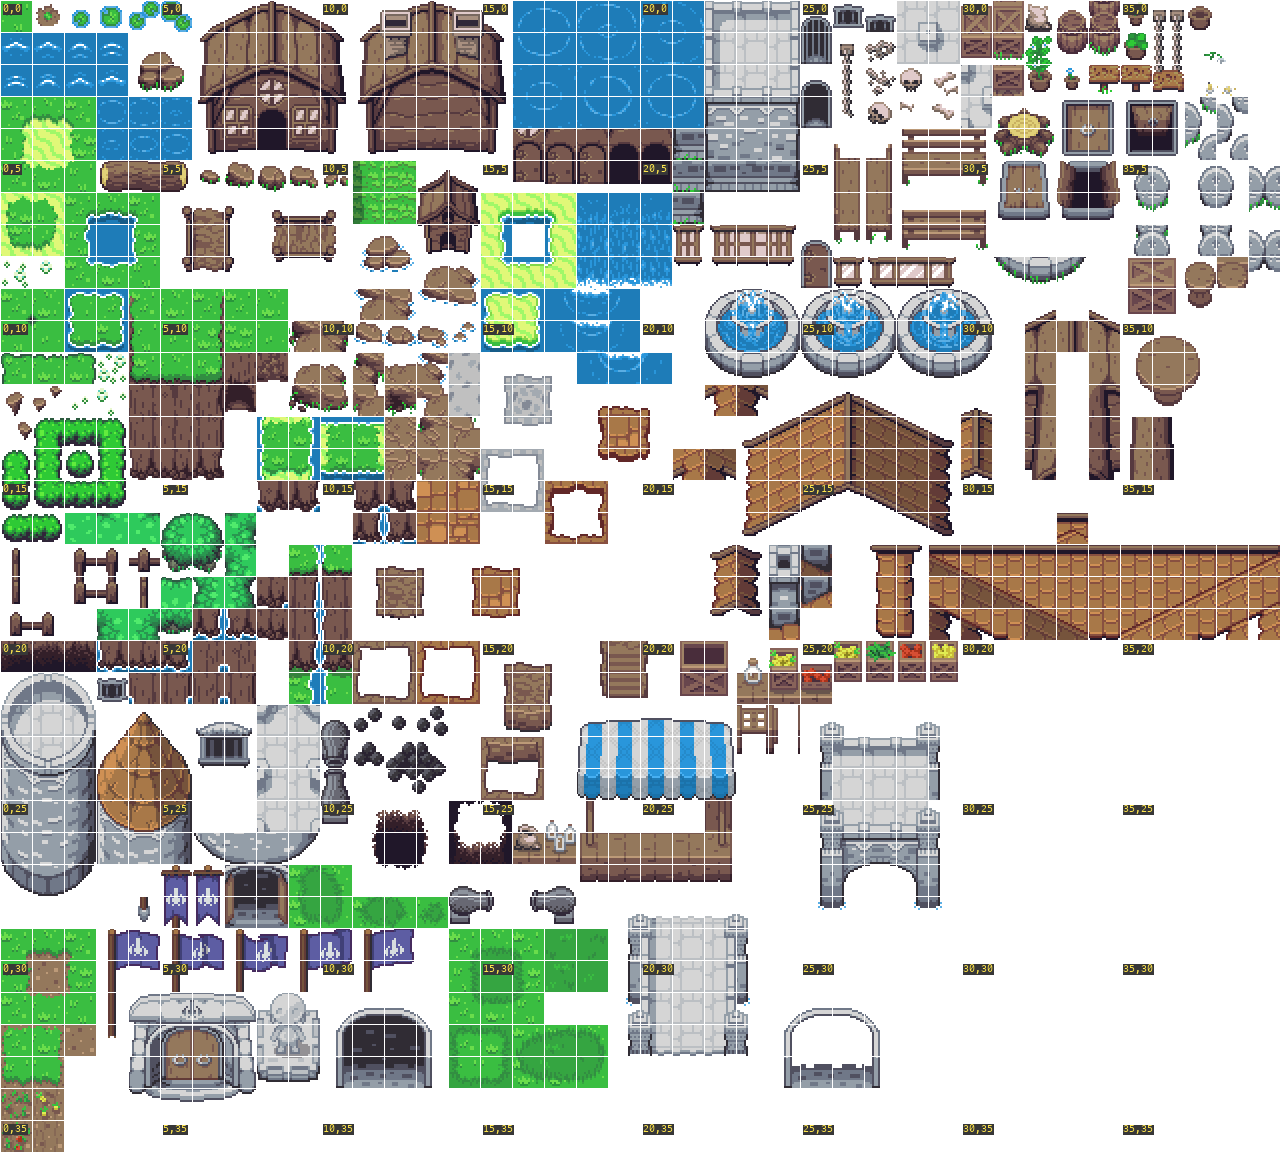

In [8]:
# 전체 시트 + 5칸마다 좌표 라벨
img = upscale(sheet, 2)
overlay_grid(img, 0, 0, scale=2, label=True, label_every=5)

## 3. 영역 잘라서 크게 보기

값을 바꿔가며 자유롭게 실험.

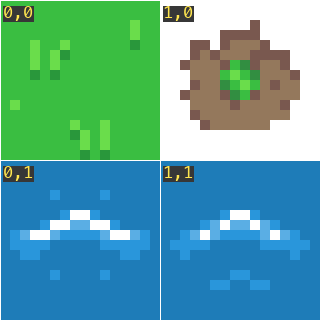

In [5]:
# 잔디 후보
show_region(0, 0, 1, 1, scale=10);

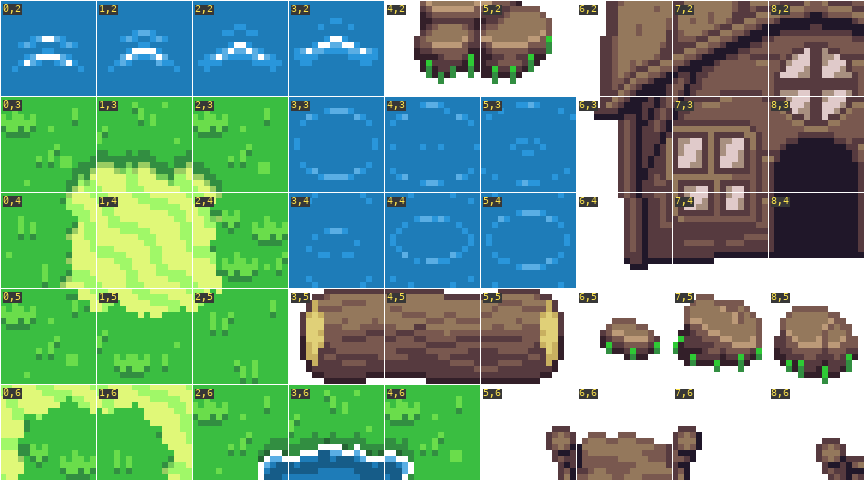

In [4]:
# 바다 후보
show_region(0, 2, 8, 6, scale=6);

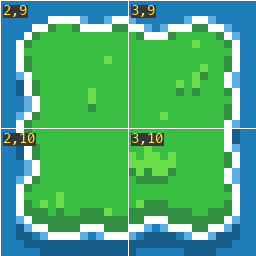

In [10]:
# 오토타일(?) 후보
show_region(2, 9, 3, 10, scale=8);

## 4. 특정 타일 한 칸씩 크게 보기

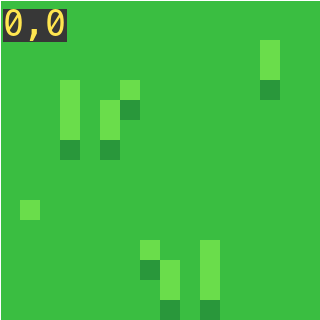

In [6]:
show_tile(0, 0, scale=20);

## 5. 흩어진 좌표 후보들 한 화면에 비교

잔디 / 자갈길 / 바다 등 후보를 늘어놓고 골라봄.

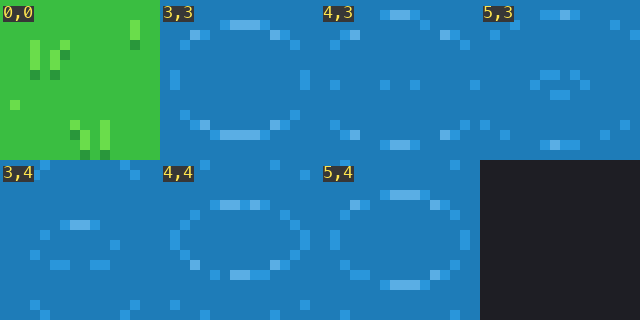

In [7]:
show_tiles([
    (0, 0),  # plain grass?
    (3, 3),  # clean water?
    (4, 3),
    (5, 3),
    (3, 4),
    (4, 4),
    (5, 4),
], scale=10, per_row=4);

## 6. 잘라서 PNG로 저장

`notebooks/_out/` 아래에 떨어짐. `scale=8` 처럼 주면 확대해서 저장.

In [8]:
# 예시: 잔디 한 칸을 4× 확대해서 저장
save_crop(0, 0, 0, 0, "grass_plain", scale=4)

saved → notebooks/_out/grass_plain.png  ((64, 64))


PosixPath('/Users/rhseung/Dev/rhseung/ec2208-game/notebooks/_out/grass_plain.png')

In [9]:
# 예시: 바다 변형 6칸 묶음 저장 (원본 크기 그대로)
save_crop(3, 3, 5, 4, "water_variants")

saved → notebooks/_out/water_variants.png  ((48, 32))


PosixPath('/Users/rhseung/Dev/rhseung/ec2208-game/notebooks/_out/water_variants.png')

In [ ]:
# 예시: 오토 타일
save_crop(2, 9, 3, 10, "grass_edge_variants")

saved → notebooks/_out/grass_edge_variants.png  ((32, 32))


PosixPath('/Users/rhseung/Dev/rhseung/ec2208-game/notebooks/_out/grass_edge_variants.png')

## 7. 선택한 타일을 게임 코드에 반영

마음에 드는 좌표가 정해지면 `renderer/tilemap.py` 의 `# TWEAK ME` 상수에 대입:

```python
GRASS_AUTOTILE_BASE = (col, row)   # 9-tile 블록 좌상단
PATH_PLAIN          = (col, row)
WATER_PLAIN         = (col, row)
```

오토타일 9칸 배치가 표준 NW/N/NE — W/center/E — SW/S/SE 순이 아니면 `_GRASS_OFFSETS` 딕셔너리도 같이 손봐야 함.